# Phase 2: Training the Shared Latent Space (Masked Autoencoder + Contrastive Alignment)

This notebook implements Phase 2 of the MIMIR pipeline: **jointly fine-tuning modality-specific autoencoders into a shared latent space**.

Starting from pretrained modality-specific encoders and decoders (Phase 1), we train a unified model that:
- Aligns representations from different modalities using a contrastive objective
- Learns to reconstruct masked features within each modality
- Supports imputation when entire modalities are missing at inference time

The result is a shared embedding space in which representations from different omics assays for the same sample are directly comparable.


## Setup

We import core PyTorch utilities along with modules defined in `src/`.
Most of the model logic—including the shared-space architecture, loss functions, and training loop—is encapsulated in reusable functions to keep this notebook focused on configuration and evaluation.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import random
from typing import Dict, List, Tuple
import pickle
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import json

In [2]:
from src.data_utils import *
from src.mae_masked import *
from src.shared_finetune import *
from src.impute import *
from src.translation import *
from src.evaluation import *

## 0.1 Data loading and shared splits

We load the full multi-omic dataset and restrict analysis to samples that are observed across all modalities.
A single set of train/validation/test splits is reused across all phases to ensure consistency in evaluation.

In [3]:
with open('tcga_redo_mlomicZ.pkl', 'rb') as f:
    multi_omic_data = pickle.load(f)
    
print(multi_omic_data.keys())

common_samples, train_idx, val_idx, test_idx = load_shared_splits_from_json(
    multi_omic_data,
    json_path='splits.json'
)
print(f"Shared N={len(common_samples)} | train={len(train_idx)} | val={len(val_idx)}| test={len(test_idx)}")

dict_keys(['cnv', 'miRNA', 'rna', 'methylation'])
Shared N=8034 | train=6409 | val=798| test=800


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

## 0.2 Joint fine-tuning into a shared space
We now jointly fine-tune all modality-specific autoencoders into a shared latent space.
Each modality encoder projects its latent representation into a common embedding space of dimension `shared_dim`.

Training uses a combination of three objectives:
1. **Reconstruction loss**: reconstruct original features from masked inputs
2. **Contrastive loss**: align embeddings from different modalities of the same sample
3. **Imputation loss**: encourage accurate reconstruction when modalities are missing

To simulate realistic missingness, we apply:
- Feature-level masking within each modality
- Modality-level dropout during training


In [6]:
model, train_hist, val_hist, tr_loader, va_loader, te_loader, opt = run_shared_finetune(
    multi_omic_data=multi_omic_data,
    common_samples=common_samples,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    model_paths={m: f"aes_redo_z/{m}_ae.pt" for m in multi_omic_data.keys()},
    device=device,
    shared_dim=256,
    proj_depth=1,
    batch_size=64,
    lr=3e-4,
    weight_decay=1e-5,
    epochs=200,
    lambda_contrast=1.0,
    lambda_impute=1.0,
    modality_dropout_prob=0.4,
    feature_mask_p_train=0.15,  # randomly mask 15% of features per modality
    feature_mask_p_val=0.15,
    alpha_mask_recon=0.5,       # 50/50 overall vs masked loss; tweak as needed
    two_path_clean_for_contrast=False,
    freeze_encoders_decoders=False,
    verbose=True
)


[Finetune] ep 001 | train tot 4.4949 | recon 1.4046 | contr 2.3316 | impute 0.7586
                 |   val  tot 4.5853 | recon 1.4872 | contr 2.4073 | impute 0.6908
[Finetune] ep 002 | train tot 3.0620 | recon 0.8690 | contr 1.6117 | impute 0.5813
                 |   val  tot 4.0407 | recon 1.2700 | contr 2.1485 | impute 0.6223
[Finetune] ep 003 | train tot 2.8743 | recon 0.7847 | contr 1.5051 | impute 0.5845
                 |   val  tot 3.7652 | recon 1.1771 | contr 1.9982 | impute 0.5898
[Finetune] ep 004 | train tot 2.3801 | recon 0.6761 | contr 1.1953 | impute 0.5086
                 |   val  tot 3.5987 | recon 1.1229 | contr 1.9044 | impute 0.5713
[Finetune] ep 005 | train tot 2.4469 | recon 0.6938 | contr 1.2226 | impute 0.5305
                 |   val  tot 3.4451 | recon 1.0792 | contr 1.8140 | impute 0.5520
[Finetune] ep 006 | train tot 2.2509 | recon 0.6787 | contr 1.0827 | impute 0.4895
                 |   val  tot 3.3606 | recon 1.0515 | contr 1.7687 | impute 0.5404
[Fin

### Key training parameters

- `shared_dim=256`: dimensionality of the shared latent space
- `lambda_contrast`: weight of the contrastive alignment loss
- `lambda_impute`: weight of the cross-modality imputation loss
- `modality_dropout_prob=0.4`: probability of dropping an entire modality during training
- `feature_mask_p_train=0.15`: fraction of features masked within each modality
- `alpha_mask_recon=0.5`: tradeoff between overall reconstruction and masked-only reconstruction


### Training dynamics

We track total loss as well as individual loss components throughout training.
Stable convergence across all loss terms indicates successful alignment without collapse or overfitting.


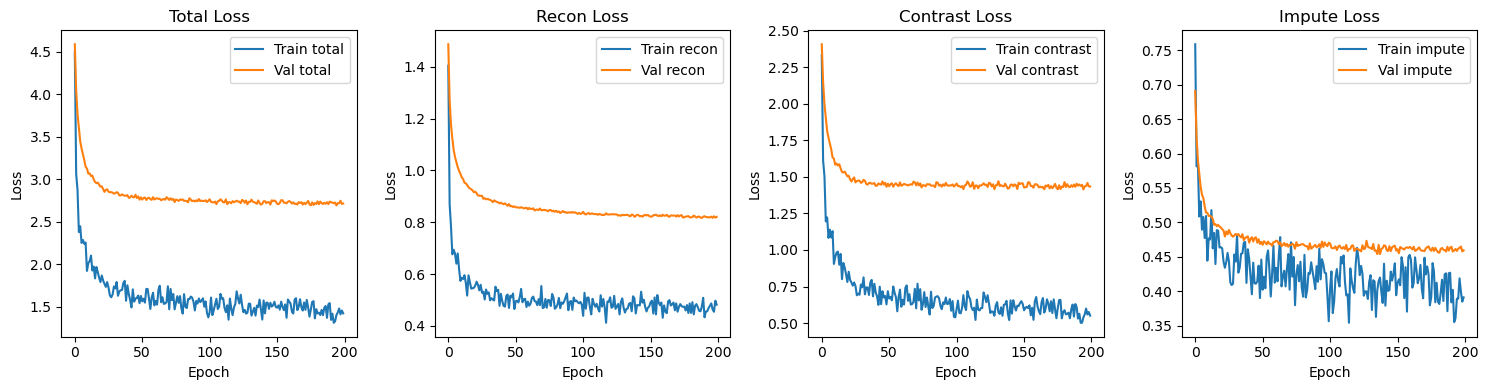

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
loss_types = ["total", "recon", "contrast", "impute"]
for i, lt in enumerate(loss_types):
    axs[i].plot(train_hist[lt], label=f"Train {lt}")
    axs[i].plot(val_hist[lt], label=f"Val {lt}")
    axs[i].set_title(f"{lt.capitalize()} Loss")
    axs[i].set_xlabel("Epoch")
    axs[i].set_ylabel("Loss")
    axs[i].legend()
plt.tight_layout()
plt.show()

The trained shared-space model is saved along with training and validation loss histories.
This checkpoint is reused for downstream imputation and analysis tasks.

In [8]:
save_shared_model(
    model,
    save_dir="checkpoints/fintuned",
    epoch=200,
    train_loss_hist=train_hist,
    val_loss_hist=val_hist
)

[Saved] Shared model checkpoint → checkpoints/fintuned/shared_model_ep200.pt


'checkpoints/fintuned/shared_model_ep200.pt'

## Summary

In this notebook, we trained a shared latent space that aligns multiple omics modalities using a combination of reconstruction, contrastive, and imputation objectives.
The resulting model supports robust cross-modality translation and serves as the foundation for downstream imputation and interpretability analyses.
